# Classificador de Risco de NEOs (PHA)

Pipeline de classificação binária supervisionada que prevê se um asteroide é
**potencialmente perigoso (PHA)**, usando apenas técnicas vistas na disciplina
(MLP, XGBoost, StandardScaler, SHAP). Fonte: **NASA NeoWs** (`browse`).

> **Nota anti-vazamento:** o rótulo PHA é definido por tamanho (H <= 22) **e**
> proximidade orbital (MOID <= 0,05 UA). Removemos o **MOID** das features; a
> magnitude absoluta (que codifica o critério de tamanho) é mantida como
> variável física legítima e isso é declarado abertamente.
>
> **Limitação declarada:** sem validação cruzada (não ensinada no fluxo manual
> da disciplina) — as métricas vêm de um único split estratificado.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from xgboost import XGBClassifier, plot_importance

from src.neo_features import FEATURE_COLUMNS, TARGET_COLUMN

RANDOM_STATE = 42


## 1. Dados e EDA

In [2]:
df = pd.read_csv("data/neos_raw.csv")
print("shape:", df.shape)
df.head()


shape: (18447, 10)


,designation,name,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,miss_distance_min_au,miss_distance_mean_au,relative_velocity_max_kms,n_close_approaches,is_potentially_hazardous_asteroid
0,1620,1620 Geographos (1951 RA),15.27,2.347226,5.248558,0.033305,0.115975,16.737430,28,1
1,1863,1863 Antinous (1948 EA),15.32,2.293797,5.129086,0.174222,0.182551,18.043920,6,0
2,1915,1915 Quetzalcoatl (1953 EA),18.38,0.560473,1.253257,0.025332,0.199618,19.519999,21,0
3,1917,1917 Cuyo (1968 AA),14.38,3.536348,7.907514,0.072944,0.118651,16.404789,6,0
4,2063,2063 Bacchus (1977 HB),17.21,0.960627,2.148028,0.067753,0.130982,16.145461,33,0


is_potentially_hazardous_asteroid
0    16528
1     1919
Name: count, dtype: int64
Prevalência de PHA no conjunto: 10.4%


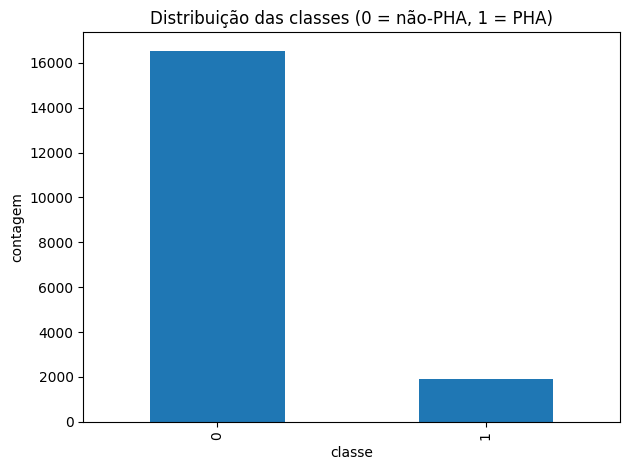

In [3]:
# Distribuição das classes (prevalência MEDIDA — não representa o catálogo inteiro;
# este é um conjunto de NEOs com histórico de aproximação registrado).
counts = df[TARGET_COLUMN].value_counts().sort_index()
prevalence = df[TARGET_COLUMN].mean()
print(counts)
print(f"Prevalência de PHA no conjunto: {prevalence:.1%}")
counts.plot(kind="bar")
plt.title("Distribuição das classes (0 = não-PHA, 1 = PHA)")
plt.xlabel("classe"); plt.ylabel("contagem"); plt.tight_layout(); plt.show()


### Correlação e redundância de tamanho

A NeoWs deriva `estimated_diameter` de `absolute_magnitude_h` (via albedo), então
os campos de tamanho são colineares por construção. O heatmap confirma isso e
justifica manter **uma única** feature de tamanho (`absolute_magnitude_h`).


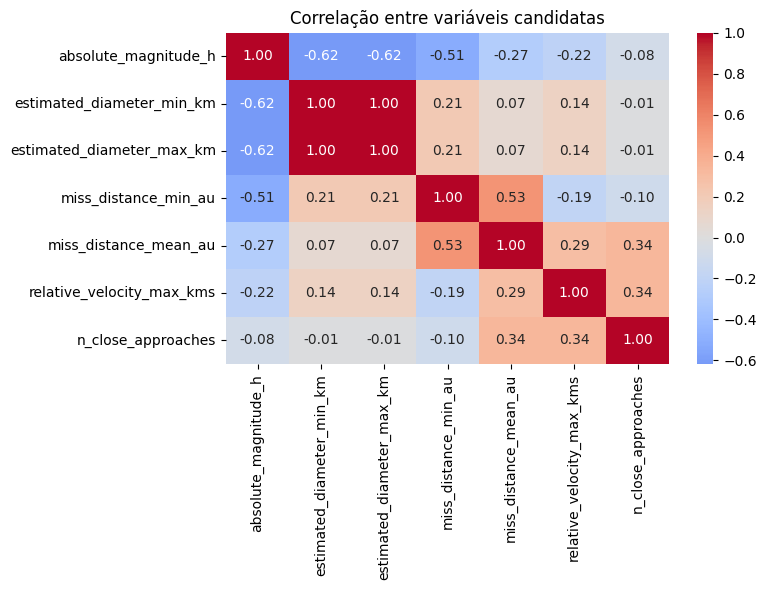

In [4]:
size_and_features = [
    "absolute_magnitude_h", "estimated_diameter_min_km", "estimated_diameter_max_km",
    "miss_distance_min_au", "miss_distance_mean_au",
    "relative_velocity_max_kms", "n_close_approaches",
]
corr = df[size_and_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre variáveis candidatas")
plt.tight_layout(); plt.show()


## 2. Pré-processamento e engenharia de atributos

- Mantemos `FEATURE_COLUMNS` (uma feature de tamanho + features de aproximação);
  os diâmetros saem por redundância (heatmap acima).
- Split **estratificado** (boa prática com classe desbalanceada).
- `StandardScaler` ajustado **apenas no treino** (evita vazamento das estatísticas
  de escala — boa prática acima do material).


In [5]:
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Escalamos e mantemos DataFrames nomeados (necessário para SHAP/plot_importance
# legíveis e para o XGBoost não reclamar de nomes de features).
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=FEATURE_COLUMNS, index=X_train.index
)  # fit só no treino
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=FEATURE_COLUMNS, index=X_test.index
)
print("treino:", X_train.shape, "| teste:", X_test.shape)
print("PHA no treino:", int(y_train.sum()), "| PHA no teste:", int(y_test.sum()))


treino: (12912, 5) | teste: (5535, 5)
PHA no treino: 1343 | PHA no teste: 576


## 3. Modelos: XGBoost e MLP

Duas técnicas distintas, ambas ensinadas. O XGBoost usa `scale_pos_weight` para o
desbalanceamento (Aula 06). O `MLPClassifier` do sklearn não tem equivalente —
essa assimetria é uma **hipótese** para um possível melhor desempenho do XGBoost
na classe minoritária, a confirmar pelos números.


In [6]:
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos
print("scale_pos_weight =", round(scale_pos_weight, 3))

xgb = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
    eval_metric="logloss",
)
xgb.fit(X_train_scaled, y_train)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation="relu",
    max_iter=500, random_state=RANDOM_STATE,
)
mlp.fit(X_train_scaled, y_train)
print("modelos treinados")


scale_pos_weight = 8.614


/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


modelos treinados


## 4. Validação e comparação

Foco em **recall/F1 da classe PHA** (a accuracy é enganosa com desbalanceamento).

In [7]:
def metrics_row(name, model):
    pred = model.predict(X_test_scaled)
    return {
        "modelo": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_PHA": precision_score(y_test, pred, zero_division=0),
        "recall_PHA": recall_score(y_test, pred, zero_division=0),
        "f1_PHA": f1_score(y_test, pred, zero_division=0),
    }

comparison = pd.DataFrame([metrics_row("XGBoost", xgb), metrics_row("MLP", mlp)])
comparison


/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,modelo,accuracy,precision_PHA,recall_PHA,f1_PHA
0,XGBoost,0.933153,0.619490,0.927083,0.742698
1,MLP,0.962240,0.856311,0.765625,0.808433


===== XGBoost =====
              precision    recall  f1-score   support

           0      0.991     0.934     0.962      4959
           1      0.619     0.927     0.743       576

    accuracy                          0.933      5535
   macro avg      0.805     0.930     0.852      5535
weighted avg      0.952     0.933     0.939      5535

===== MLP =====
              precision    recall  f1-score   support

           0      0.973     0.985     0.979      4959
           1      0.856     0.766     0.808       576

    accuracy                          0.962      5535
   macro avg      0.915     0.875     0.894      5535
weighted avg      0.961     0.962     0.961      5535



/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Us

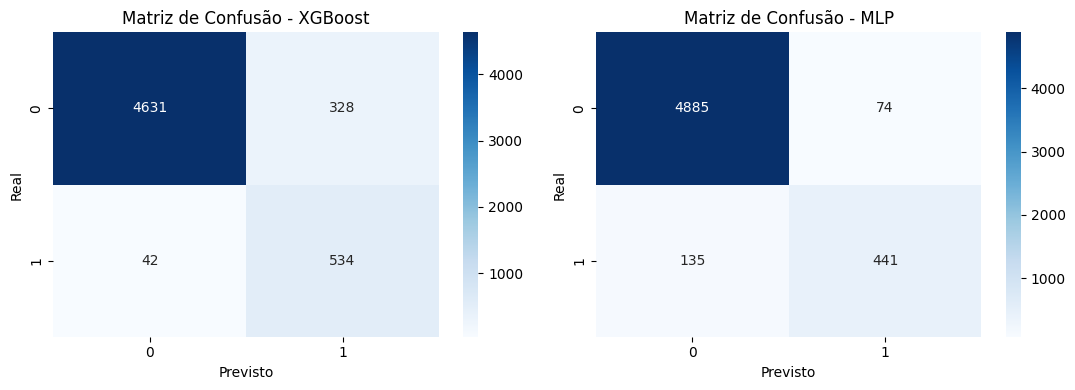

In [8]:
for name, model in [("XGBoost", xgb), ("MLP", mlp)]:
    pred = model.predict(X_test_scaled)
    print(f"===== {name} =====")
    print(classification_report(y_test, pred, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, model) in zip(axes, [("XGBoost", xgb), ("MLP", mlp)]):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de Confusão - {name}")
    ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()


## 5. Interpretabilidade com SHAP (sobre o XGBoost)

O SHAP ensinado (Aula 06) é para modelos de árvore; por isso a interpretabilidade é feita sobre o XGBoost.

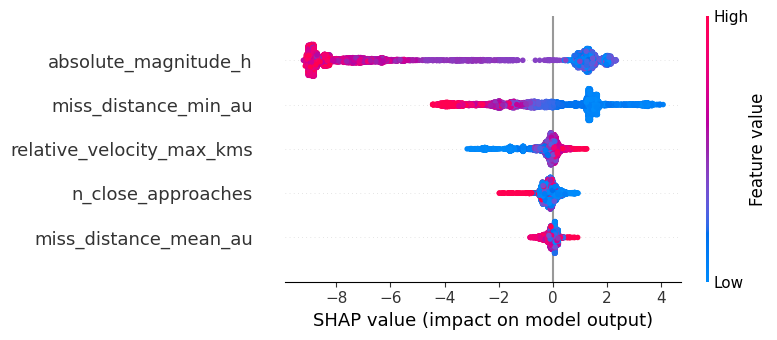

In [9]:
# SHAP no MESMO espaço em que o modelo foi treinado (escalado), com nomes.
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, show=True)


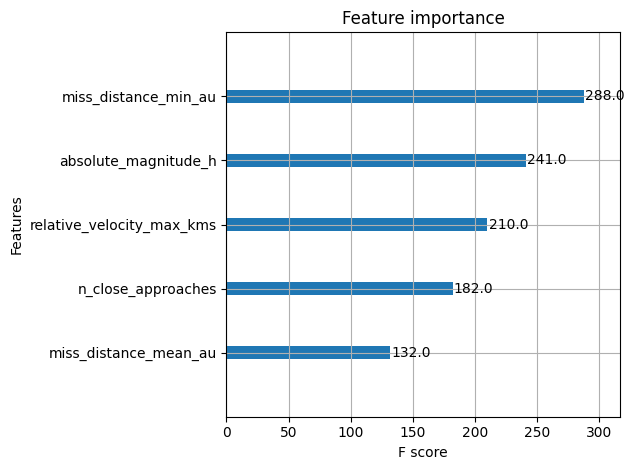

In [10]:
plot_importance(xgb)
plt.tight_layout(); plt.show()


**Interpretação:** espera-se que `absolute_magnitude_h` (tamanho) e as variáveis
de proximidade (`miss_distance_*`) dominem a decisão — coerente com a definição de
PHA (tamanho + proximidade). Isso é consequência direta de manter a magnitude como
feature, e está documentado.


## 6. Escolha e persistência do modelo final

As duas técnicas mostram um **trade-off claro**, e a hipótese da Aula (o `scale_pos_weight` ajudaria o XGBoost na classe minoritária) confirma-se de forma **parcial e instrutiva**:

- **XGBoost**: recall_PHA alto (~0,93) com precision menor (~0,62) — o `scale_pos_weight` empurra o modelo a sinalizar mais asteroides como perigosos (mais recall, mais falsos positivos).
- **MLP**: melhor **F1 e accuracy**, mais equilibrado (precision ~0,86, recall ~0,77).

**Critério de escolha = recall da classe PHA**, por razão de domínio: em triagem de defesa planetária, **deixar de sinalizar um asteroide perigoso (falso negativo) é muito mais caro** do que um falso alarme (que apenas gera observação de acompanhamento). Sob esse critério escolhemos o **XGBoost** (recall ~0,93 vs ~0,77 do MLP — deixa escapar ~3x menos perigos). O **F1 e a accuracy favorecem o MLP**, e isso é reportado abertamente. A interpretabilidade (SHAP) é feita sobre o modelo escolhido (XGBoost, de árvore).


In [11]:
# Critério de seleção: RECALL da classe PHA (domínio de segurança — falso negativo
# é mais caro que falso positivo). Reportamos os dois modelos abertamente acima.
scores = {"XGBoost": (xgb, comparison.loc[0, "recall_PHA"]),
          "MLP": (mlp, comparison.loc[1, "recall_PHA"])}
best_name = max(scores, key=lambda k: scores[k][1])
best_model = scores[best_name][0]
print("modelo final (criterio: recall da classe PHA):", best_name)
print(comparison.to_string(index=False))

joblib.dump(
    {"model": best_model, "scaler": scaler, "features": FEATURE_COLUMNS,
     "best_name": best_name},
    "model.joblib",
)
print("salvo em model.joblib")


modelo final (criterio: recall da classe PHA): XGBoost
 modelo  accuracy  precision_PHA  recall_PHA   f1_PHA
XGBoost  0.933153       0.619490    0.927083 0.742698
    MLP  0.962240       0.856311    0.765625 0.808433
salvo em model.joblib
